# Exploring how to make cyclone relative composites using TempestExtremes NodeFileFilter and NodeFileCompose

In [2]:
### Importing necessary packages
import pandas as pd
import os
from pathlib import Path
import re
import warnings

#warnings.filterwarnings('ignore')
import matplotlib 
import matplotlib.pyplot as plt
import matplotlib.colors as col
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import cmocean
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np
import seaborn as sns
import xarray as xr

## custom packages:
from download_era5_composite import timestamps_from_etc_summary, build_date_groups, download, OUT_DIR

## Creating two TempestExtremes nodefiles, each with one node per cyclone (the node at that cyclone's time_min_msl)

Full **DJFM 1996–2025** run. December is treated as in-season and attached to the **following** year's JFM (e.g. Dec 2019 → season 2020).

In [ ]:
## full 1995-2025 summaries 
etc_summary = pd.read_csv('data/etc_summary_final.csv').drop(columns='Unnamed: 0')
nodes_with_reports = pd.read_csv('data/nodes_with_reports_final.csv')

In [29]:
etc_summary

,track_id,track_start,track_end,time_min_msl,min_msl,n_steps,n_reports,n_tornado,n_hail,n_wind,n_cores_total,n_cores_kept,kept_reports,max_core_reports,time_max_reports
0,1.0,1995-12-01 00:00:00+00:00,1995-12-06 23:00:00+00:00,1995-12-02 22:00:00+00:00,980.3069,144,0,0,0,0,0,0,0,0,NaT
1,2.0,1995-12-01 00:00:00+00:00,1995-12-12 03:00:00+00:00,1995-12-10 06:00:00+00:00,961.9612,251,0,0,0,0,0,0,0,0,NaT
2,3.0,1995-12-03 06:00:00+00:00,1995-12-07 01:00:00+00:00,1995-12-05 04:00:00+00:00,994.3956,92,1,1,0,0,0,0,0,0,1995-12-06 04:00:00+00:00
3,4.0,1995-12-04 04:00:00+00:00,1995-12-06 04:00:00+00:00,1995-12-06 04:00:00+00:00,978.0338,49,0,0,0,0,0,0,0,0,NaT
4,5.0,1995-12-06 17:00:00+00:00,1995-12-08 01:00:00+00:00,1995-12-07 19:00:00+00:00,980.9462,31,0,0,0,0,0,0,0,0,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2220,6114.0,2025-03-24 18:00:00+00:00,2025-03-29 11:00:00+00:00,2025-03-27 22:00:00+00:00,1005.1210,106,5,0,4,1,1,0,0,0,2025-03-28 21:00:00+00:00
2221,6116.0,2025-03-26 17:00:00+00:00,2025-03-30 19:00:00+00:00,2025-03-29 10:00:00+00:00,982.2738,99,0,0,0,0,0,0,0,0,NaT
2222,6117.0,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,2025-03-31 20:00:00+00:00,992.6212,114,927,66,277,584,7,2,891,821,2025-03-30 20:00:00+00:00
2223,6119.0,2025-03-28 20:00:00+00:00,2025-03-31 21:00:00+00:00,2025-03-30 23:00:00+00:00,989.9344,73,1,0,1,0,0,0,0,0,2025-03-31 21:00:00+00:00


In [20]:
MASTER_NODEFILE = "/data1/lepique/TempestExtremes/tracks/tracks_hourly_1995_2025.txt"  

def diagnose(master_nodefile, etc_summary):
    print("=== etc_summary columns ===")
    print(list(etc_summary.columns))
    print("\n=== etc_summary dtypes (relevant) ===")
    print(etc_summary.dtypes)
    print("\n=== etc_summary head ===")
    print(etc_summary.head())

    print("\n=== first 6 lines of master nodefile ===")
    with open(master_nodefile) as f:
        for i, line in enumerate(f):
            print(repr(line.rstrip("\n")))
            if i >= 5:
                break

In [21]:
diagnose(MASTER_NODEFILE, etc_summary)

=== etc_summary columns ===
['track_id', 'track_start', 'track_end', 'time_min_msl', 'min_msl', 'n_steps', 'n_reports', 'n_tornado', 'n_hail', 'n_wind', 'n_cores_total', 'n_cores_kept', 'kept_reports', 'max_core_reports']

=== etc_summary dtypes (relevant) ===
track_id            float64
track_start          object
track_end            object
time_min_msl         object
min_msl             float64
n_steps               int64
n_reports             int64
n_tornado             int64
n_hail                int64
n_wind                int64
n_cores_total         int64
n_cores_kept          int64
kept_reports          int64
max_core_reports      int64
dtype: object

=== etc_summary head ===
   track_id                track_start                  track_end  \
0       1.0  1995-12-01 00:00:00+00:00  1995-12-06 23:00:00+00:00   
1       2.0  1995-12-01 00:00:00+00:00  1995-12-12 03:00:00+00:00   
2       3.0  1995-12-03 06:00:00+00:00  1995-12-07 01:00:00+00:00   
3       4.0  1995-12-04 04:00:0

In [36]:
## CONFIG
REFERENCE = "min_msl" ## time to center the composite on (can use "max_reports")
COL_TRACKID = "track_id"
COL_NREPORTS = "n_reports"
COL_NCORESKEPT = "n_cores_kept"
COL_TIMEMAXREP = "time_max_reports"
COL_TIMEMSL = "time_min_msl"
REF_TIME_COL = COL_TIMEMSL if REFERENCE == "min_msl" else COL_TIMEMAXREP


## node data columns AFTER the two grid indices:
NODE_DATA_COLS = ["lon", "lat", "msl", "phis"]

## OC / NOC split: a cyclone is an "outbreak cyclone" if it has at least
## OUTBREAK_MIN_CORES kept cores (n_cores_kept >= OUTBREAK_MIN_CORES). NOC =
## fewer than that. Together these partition every in-season cyclone.
## (Earlier this was based on n_reports > 0.)
OUTBREAK_MIN_CORES = 1

## DJFM season for the full 1996-2025 run. December is in-season and is attached
## to the FOLLOWING year's JFM (e.g. Dec 2019 -> season 2020), via season_year().
MONTHS = (12, 1, 2, 3)

def season_year(ts):
    """DJFM season label: December belongs to the following year's JFM season."""
    ts = pd.Timestamp(ts)
    return ts.year + 1 if ts.month == 12 else ts.year

OUT_OC = "outbreak_cyclones_min_msl_cores.txt"
OUT_NOC = "nonoutbreak_cyclones_min_msl_cores.txt"

## ERA5 domain [N, W, S, E] -- kept in sync with download_era5_composite.py,
## which holds the authoritative ERA5 download config (variables, levels, the
## 9 min-MSL +/- offset reference times). Used here only for the southern-
## boundary check in select_reference_nodes.
ERA5_AREA = [70, -140, -10, -50]

In [37]:
## new helper to compute each cylone's max reports time
def add_max_report_time(etc_summary, node_reports,
                        id_col="track_id", time_col="time_hour",
                        rep_col="n_reports"):
    nr = node_reports.copy()
    nr[time_col] = pd.to_datetime(nr[time_col], utc=True)
    # most reporting node per track; ties -> earliest time
    top = (nr.sort_values([id_col, rep_col, time_col],
                          ascending=[True, False, True])
             .groupby(id_col, as_index=False)
             .head(1))
    # max-report time is only meaningful when the track actually has reports;
    # tracks with 0 reports get NaN (filled with min-MSL below)
    top = top[top[rep_col] > 0]
    time_max = top.set_index(id_col)[time_col]
    es = etc_summary.copy()
    es[COL_TIMEMAXREP] = es[COL_TRACKID].map(time_max)
    return es

etc_summary = add_max_report_time(etc_summary, nodes_with_reports)
#etc_summary[REF_TIME_COL] = etc_summary[COL_TIMEMAXREP].fillna(etc_summary[COL_TIMEMSL]) ## this fills time-max-reports column with the min-msl time for cyclones with no reports, but I don't think I want to actually do that

In [38]:
## Parse nodefile 
def parse_nodefile(path, data_cols):
    """
    Parse TE StitchNodes nodefile. track_id is 1-indexed (first block = 1) to
    match etc_summary. Datetime build is vectorized so it scales to the full
    1996-2025 record.
    """

    rows = []
    with open(path) as f:
        lines = [ln.rstrip("\n") for ln in f]

    i = 0
    tid = 0
    n_data = len(data_cols)
    while i < len(lines):
        parts = lines[i].split()
        if not parts:
            i += 1
            continue
        if parts[0] == "start":
            tid +=1
            n_steps = int(parts[1])
            for k in range(1, n_steps + 1):
                np_ = lines[i+k].split()
                grid_i, grid_j = int(np_[0]), int(np_[1])
                data_vals = np_[2:2 + n_data]
                yyyy, mm, dd, off = np_[2 + n_data:2 + n_data + 4]
                row = {
                    "track_id": float(tid),
                    "grid_i": grid_i, "grid_j": grid_j,
                    "year": int(yyyy), "month": int(mm),
                    "day": int(dd), "offset": off,
                }
                for c, v in zip(data_cols, data_vals):
                    row[c] = float(v)
                rows.append(row)
            i += n_steps + 1
        else:
            i +=1
    
    df = pd.DataFrame(rows)
    ## "offset" is the hour-of-day field; build tz-aware UTC datetimes vectorized
    df["datetime"] = (
        pd.to_datetime(dict(year=df["year"], month=df["month"], day=df["day"]),
                       utc=True)
        + pd.to_timedelta(df["offset"].astype(float), unit="h")
    )

    return df


In [39]:
## label OC/NOC, pick reference node
def select_reference_nodes(nodes_df, etc_summary, ref_time_col):
    es = etc_summary[[COL_TRACKID, COL_NREPORTS, COL_NCORESKEPT, ref_time_col]].copy()
    es[ref_time_col] = pd.to_datetime(es[ref_time_col], utc=True)
    es = es.dropna(subset=[ref_time_col])              ## need a reference time
    es = es[es[ref_time_col].dt.month.isin(MONTHS)]    ## DJFM only (December in-season)
    es["is_oc"] = es[COL_NCORESKEPT] >= OUTBREAK_MIN_CORES  ## >=1 kept core -> outbreak; else NOC
    es["season_year"] = es[ref_time_col].apply(season_year)   ## Dec -> following JFM

    ## vectorized nearest-node pick (scales to the full 1996-2025 record)
    merged = nodes_df.merge(
        es[[COL_TRACKID, ref_time_col, COL_NREPORTS, COL_NCORESKEPT, "is_oc", "season_year"]],
        on=COL_TRACKID, how="inner",
    )
    merged["dt_diff"] = (merged["datetime"] - merged[ref_time_col]).abs()
    idx = merged.groupby(COL_TRACKID)["dt_diff"].idxmin()
    picks_df = merged.loc[idx].sort_values(COL_TRACKID).reset_index(drop=True)

    ## tracks requested (in-season, with a reference time) but absent from the nodefile
    missing = sorted(set(es[COL_TRACKID]) - set(picks_df[COL_TRACKID]))
    if missing:
        head = ", ".join(f"{m:.0f}" for m in missing[:10])
        print(f"WARNING: {len(missing)} track(s) not in nodefile: {head}"
              f"{' ...' if len(missing) > 10 else ''}")

    ## flag any pick whose nearest node is > 1 h from the reference time
    far = picks_df[picks_df["dt_diff"] > pd.Timedelta(hours=1)]
    for _, n in far.iterrows():
        print(f"NOTE: track {n[COL_TRACKID]:.0f} nearest node "
              f"{n['dt_diff']} from {ref_time_col}")

    print(f"\n  DJFM seasons : {picks_df['season_year'].min():.0f}-"
          f"{picks_df['season_year'].max():.0f} "
          f"({picks_df['season_year'].nunique()} seasons)")
    print(f"  OC  (>={OUTBREAK_MIN_CORES} kept core): {int(picks_df['is_oc'].sum())}")
    print(f"  NOC (<{OUTBREAK_MIN_CORES} kept core) : {int((~picks_df['is_oc']).sum())}")

    ## per-season OC / NOC / total (record-keeping for the full period)
    by_season = picks_df.groupby("season_year")["is_oc"].agg(OC="sum", total="size")
    by_season["NOC"] = by_season["total"] - by_season["OC"]
    print("\n  per-season (OC / NOC / total):")
    for yr, r in by_season.iterrows():
        print(f"    {yr:.0f}: {int(r['OC']):4d} / {int(r['NOC']):4d} / {int(r['total']):4d}")

    ## warn if any node is within ~20 deg of the ERA5 southern boundary
    south_edge = ERA5_AREA[2]
    too_south = picks_df[picks_df["lat"] - 20 < south_edge]
    if len(too_south):
        print(f"\n  DOMAIN WARNING: {len(too_south)} node(s) within 20 deg of "
              f"southern boundary ({south_edge} N):")
        for _, n in too_south.iterrows():
            print(f"    track {n['track_id']:.0f}  lat={n['lat']:.2f}  "
                  f"-> radius reaches {n['lat']-20:.1f} N")
    return picks_df

In [40]:
## write single-snapshot nodefiles (what will be the input to TE)
def write_snapshot_nodefile(subset, out_path, data_cols):
    with open(out_path, "w") as f:
        for _, r in subset.iterrows():
            yyyy, mm, dd, off = int(r["year"]), int(r["month"]), int(r["day"]), r["offset"]
            data_str = "\t".join(f"{r[c]:.6f}" for c in data_cols)
            f.write(f"start\t1\t{yyyy}\t{mm}\t{dd}\t{off}\n")
            f.write(f"\t{int(r['grid_i'])}\t{int(r['grid_j'])}\t{data_str}"
                    f"\t{yyyy}\t{mm}\t{dd}\t{off}\n")
    print(f" wrote {len(subset)} -> {out_path}")

In [41]:
## driver: build the two single-node-per-cyclone nodefiles for NodeFileCompose
## over the full DJFM 1996-2025 record. OC = cyclones with >=1 kept core,
## NOC = no kept cores -> outbreak_cyclones_min_msl.txt,
## nonoutbreak_cyclones_min_msl.txt
def run_all(master_nodefile, etc_summary, ref_time_col=REF_TIME_COL):
    nodes_df = parse_nodefile(master_nodefile, NODE_DATA_COLS)
    print(f"Parsed {nodes_df['track_id'].nunique()} tracks, {len(nodes_df)} nodes.")
    picks_df = select_reference_nodes(nodes_df, etc_summary, ref_time_col)
    write_snapshot_nodefile(picks_df[picks_df["is_oc"]],  OUT_OC,  NODE_DATA_COLS)
    write_snapshot_nodefile(picks_df[~picks_df["is_oc"]], OUT_NOC, NODE_DATA_COLS)
    return nodes_df, picks_df

In [42]:
nodes_df, picks_df = run_all(MASTER_NODEFILE, etc_summary)

Parsed 6263 tracks, 849713 nodes.

  DJFM seasons : 1996-2025 (30 seasons)
  OC  (>=1 kept core): 270
  NOC (<1 kept core) : 1955

  per-season (OC / NOC / total):
    1996:    8 /   57 /   65
    1997:   14 /   71 /   85
    1998:   12 /   54 /   66
    1999:   11 /   63 /   74
    2000:   10 /   68 /   78
    2001:    7 /   73 /   80
    2002:    6 /   69 /   75
    2003:    6 /   63 /   69
    2004:    3 /   79 /   82
    2005:   12 /   63 /   75
    2006:   12 /   58 /   70
    2007:    8 /   61 /   69
    2008:   15 /   66 /   81
    2009:   10 /   63 /   73
    2010:    4 /   63 /   67
    2011:   11 /   65 /   76
    2012:   13 /   63 /   76
    2013:   12 /   60 /   72
    2014:    4 /   76 /   80
    2015:    3 /   69 /   72
    2016:   12 /   54 /   66
    2017:   17 /   64 /   81
    2018:    5 /   61 /   66
    2019:   10 /   58 /   68
    2020:    9 /   70 /   79
    2021:    6 /   71 /   77
    2022:    8 /   80 /   88
    2023:    9 /   62 /   71
    2024:    4 /   77 / 

Use python script (@download_era5_composite.py) to download the corresponding ERA5 data to input into NodeFileCompose to generate composites

## Downloading ERA5 data for NodeFileCompose

use python script 

## Plotting Composite Output

### MSL:

In [53]:
ds = xr.open_dataset('data/test_z500.nc')
ds

<xarray.Dataset> Size: 27kB
Dimensions:  (y: 80, x: 80)
Coordinates:
  * y        (y) float64 640B -39.5 -38.5 -37.5 -36.5 ... 36.5 37.5 38.5 39.5
  * x        (x) float64 640B -39.5 -38.5 -37.5 -36.5 ... 36.5 37.5 38.5 39.5
Data variables:
    z(12)    (y, x) float32 26kB ...

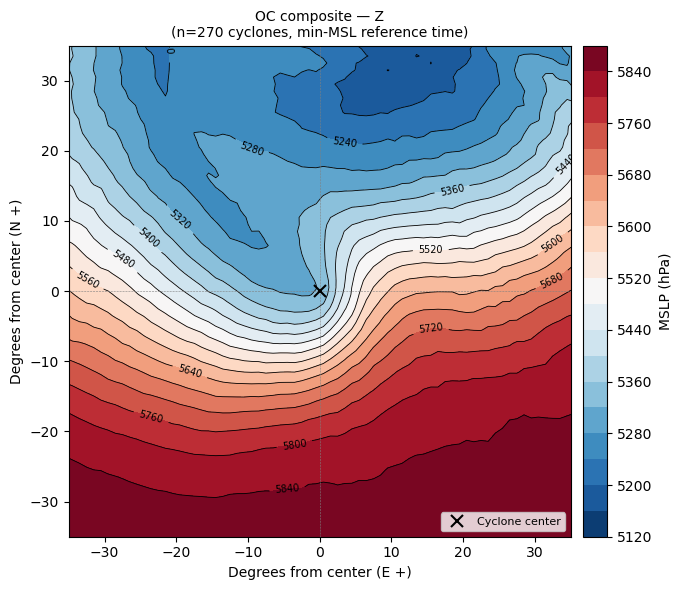

In [55]:
ds = xr.open_dataset('data/test_z500.nc')

z = ds['z(12)'] / 9.80665  #geopotential to geopotenial height

fig, ax = plt.subplots(figsize=(7,6))

# filled contours for background shading
cf = ax.contourf(
    ds["x"], ds["y"], z,
    levels=20,
    cmap="RdBu_r",
)

# line contours with labels
cs = ax.contour(
    ds["x"], ds["y"], z,
    levels=20,
    colors="k",
    linewidths=0.6,
)
ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")

# mark cyclone center
ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.4, linestyle="--")
ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5, label="Cyclone center")

cbar = fig.colorbar(cf, ax=ax, pad=0.02)
cbar.set_label("MSLP (hPa)", fontsize=10)

ax.set_xlabel("Degrees from center (E +)", fontsize=10)
ax.set_ylabel("Degrees from center (N +)", fontsize=10)
ax.set_xlim(-35,35)
ax.set_ylim(-35,35)
ax.set_title("OC composite — Z\n(n=270 cyclones, min-MSL reference time)", fontsize=10)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

In [12]:
ds_oc = xr.open_dataset('test_oc_msl.nc')
ds_noc = xr.open_dataset('test_noc_msl.nc')

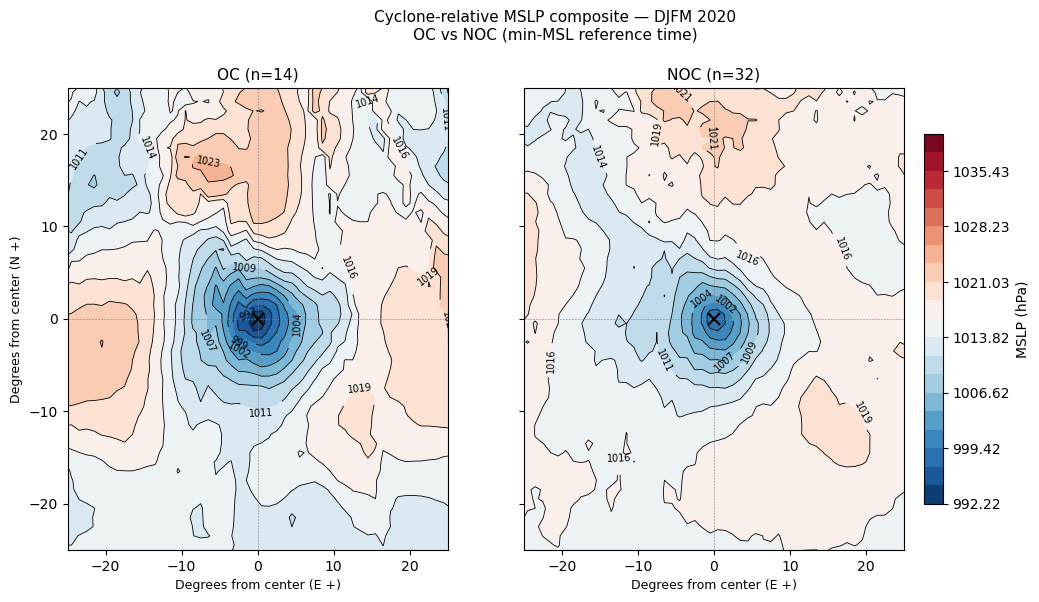

In [22]:
ds_oc  = xr.open_dataset("test_oc_msl.nc")
ds_noc = xr.open_dataset("test_noc_msl.nc")

msl_oc  = ds_oc["msl"]  / 100   # Pa -> hPa
msl_noc = ds_noc["msl"] / 100

# Shared contour levels across both panels for direct comparability
vmin = min(np.nanmin(msl_oc.values), np.nanmin(msl_noc.values))
vmax = max(np.nanmax(msl_oc.values), np.nanmax(msl_noc.values))
levels = np.linspace(vmin, vmax, 21)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

for ax, msl, title in zip(
    axes,
    [msl_oc, msl_noc],
    [f"OC (n=14)", f"NOC (n=32)"],
):
    cf = ax.contourf(
        ds_oc["x"], ds_oc["y"], msl,
        levels=levels, cmap="RdBu_r",
    )
    cs = ax.contour(
        ds_oc["x"], ds_oc["y"], msl,
        levels=levels, colors="k", linewidths=0.6,
    )
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
    ax.set_xlim(-25, 25)
    ax.set_ylim(-25, 25)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Degrees from center (E +)", fontsize=9)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

# Single shared colorbar on the right
cbar = fig.colorbar(cf, ax=axes, pad=0.02, shrink=0.8)
cbar.set_label("MSLP (hPa)", fontsize=10)

fig.suptitle("Cyclone-relative MSLP composite — DJFM 2020\nOC vs NOC (min-MSL reference time)",
             fontsize=11, y=1.01)

#plt.tight_layout()
#plt.savefig("oc_noc_msl_composite.png", dpi=180, bbox_inches="tight")
plt.show()

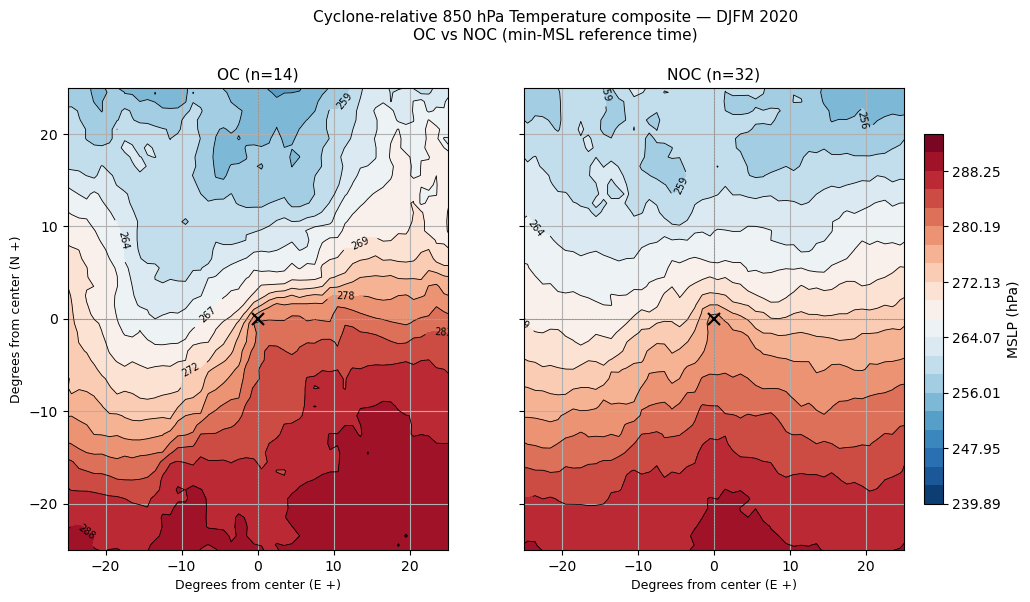

In [20]:
ds_oc  = xr.open_dataset("test_oc_t.nc")
ds_noc = xr.open_dataset("test_noc_t.nc")

t_oc  = ds_oc["t(0)"]  
t_noc = ds_noc["t(0)"] 

# Shared contour levels across both panels for direct comparability
vmin = min(np.nanmin(t_oc.values), np.nanmin(t_noc.values))
vmax = max(np.nanmax(t_oc.values), np.nanmax(t_noc.values))
levels = np.linspace(vmin, vmax, 21)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

for ax, msl, title in zip(
    axes,
    [t_oc, t_noc],
    [f"OC (n=14)", f"NOC (n=32)"],
):
    cf = ax.contourf(
        ds_oc["x"], ds_oc["y"], msl,
        levels=levels, cmap="RdBu_r",
    )
    cs = ax.contour(
        ds_oc["x"], ds_oc["y"], msl,
        levels=levels, colors="k", linewidths=0.6,
    )
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
    ax.set_xlim(-25, 25)
    ax.set_ylim(-25, 25)
    ax.grid(True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Degrees from center (E +)", fontsize=9)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

# Single shared colorbar on the right
cbar = fig.colorbar(cf, ax=axes, pad=0.02, shrink=0.8)
cbar.set_label("MSLP (hPa)", fontsize=10)

fig.suptitle("Cyclone-relative 850 hPa Temperature composite — DJFM 2020\nOC vs NOC (min-MSL reference time)",
             fontsize=11, y=1.01)

#plt.tight_layout()
#plt.savefig("oc_noc_msl_composite.png", dpi=180, bbox_inches="tight")
plt.show()

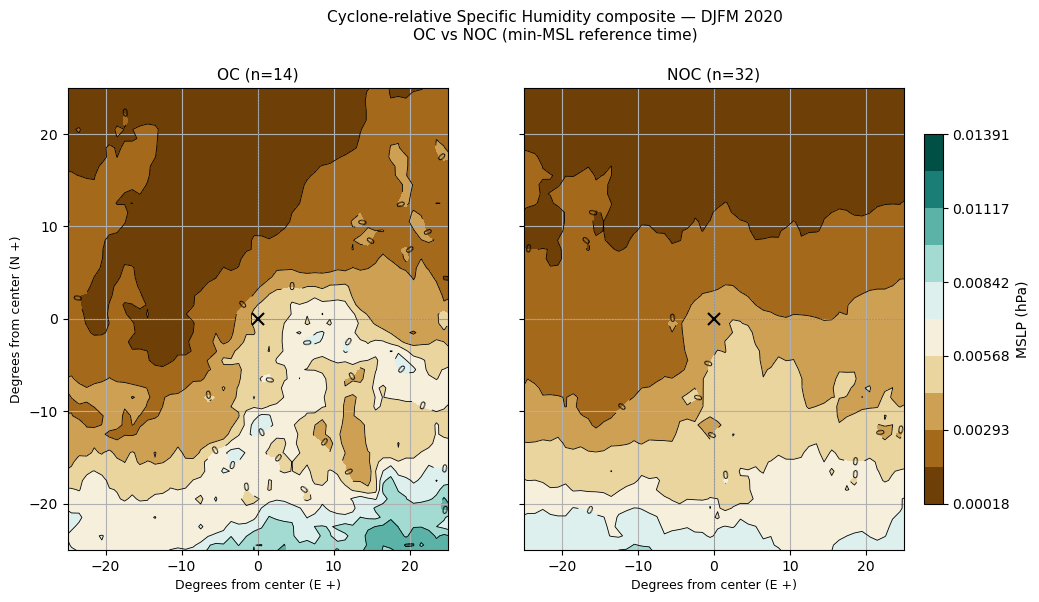

In [ ]:
ds_oc  = xr.open_dataset("test_oc_q.nc")
ds_noc = xr.open_dataset("test_noc_q.nc")

q_oc  = ds_oc["q(0)"]      
q_noc = ds_noc["q(0)"]  

# Shared contour levels across both panels for direct comparability
vmin = min(np.nanmin(q_oc.values), np.nanmin(q_noc.values))
vmax = max(np.nanmax(q_oc.values), np.nanmax(q_noc.values))
levels = np.linspace(vmin, vmax, 11)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

for ax, msl, title in zip(
    axes,
    [q_oc, q_noc],
    [f"OC (n=14)", f"NOC (n=32)"],
):
    cf = ax.contourf(
        ds_oc["x"], ds_oc["y"], msl,
        levels=levels, cmap="BrBG",
    )
    cs = ax.contour(
        ds_oc["x"], ds_oc["y"], msl,
        levels=levels, colors="k", linewidths=0.6,
    )
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
    ax.set_xlim(-25, 25)
    ax.set_ylim(-25, 25)
    ax.grid(True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Degrees from center (E +)", fontsize=9)
    

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

# Single shared colorbar on the right
cbar = fig.colorbar(cf, ax=axes, pad=0.02, shrink=0.8)
cbar.set_label("MSLP (hPa)", fontsize=10)

fig.suptitle("Cyclone-relative Specific Humidity composite — DJFM 2020\nOC vs NOC (min-MSL reference time)",
             fontsize=11, y=1.01)

#plt.tight_layout()
#plt.savefig("oc_noc_msl_composite.png", dpi=180, bbox_inches="tight")
plt.show()

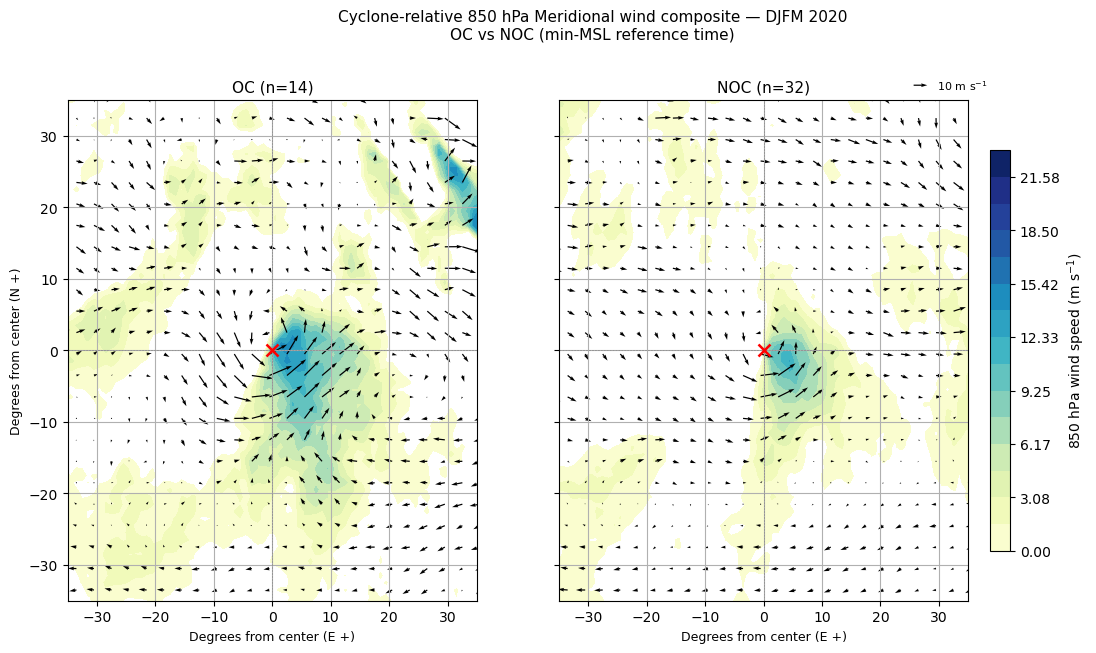

In [3]:

# --- load both populations ---
u_oc  = xr.open_dataset("test_oc_u.nc")["u(0)"]
v_oc  = xr.open_dataset("test_oc_v.nc")["v(0)"]
u_noc = xr.open_dataset("test_noc_u.nc")["u(0)"]
v_noc = xr.open_dataset("test_noc_v.nc")["v(0)"]

spd_oc  = np.sqrt(u_oc**2  + v_oc**2)
spd_noc = np.sqrt(u_noc**2 + v_noc**2)

x = u_oc["x"]
y = u_oc["y"]

# shared speed scale across both panels for comparability
vmax = max(np.nanmax(spd_oc.values), np.nanmax(spd_noc.values))
levels = np.linspace(0, vmax, 16)

skip = 3
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), sharey=True)

panels = [
    (axes[0], u_oc,  v_oc,  spd_oc,  "OC (n=14)"),
    (axes[1], u_noc, v_noc, spd_noc, "NOC (n=32)"),
]

for ax, u, v, spd, title in panels:
    cf = ax.contourf(x, y, v, levels=levels, cmap="YlGnBu")

    q = ax.quiver(
        x[::skip], y[::skip],
        u[::skip, ::skip], v[::skip, ::skip],
        scale=300, width=0.003, color="black",
    )

    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.plot(0, 0, "rx", markersize=9, markeredgewidth=1.8)
    ax.grid(True)
    ax.set_xlim(-35, 35)
    ax.set_ylim(-35, 35)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Degrees from center (E +)", fontsize=9)

# reference arrow on the second panel
ax.quiverkey(q, 0.9, 1.03, 10, "10 m s$^{-1}$",
             labelpos="E", fontproperties={"size": 8})

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

# single shared colorbar
cbar = fig.colorbar(cf, ax=axes, pad=0.02, shrink=0.8)
cbar.set_label("850 hPa wind speed (m s$^{-1}$)", fontsize=10)

fig.suptitle("Cyclone-relative 850 hPa Meridional wind composite — DJFM 2020\nOC vs NOC (min-MSL reference time)",
             fontsize=11, y=1.02)

#plt.savefig("oc_noc_wind850_composite.png", dpi=180, bbox_inches="tight")
plt.show()

## Adding core onset and peak report time to core_summary dataframe

In [11]:
etc_summary = pd.read_csv('data/etc_summary_final.csv')
reports = pd.read_csv('data/reports_tagged_final.csv', low_memory=False)
cores = pd.read_csv('data/kde_core_summary.csv')

In [33]:
msl_map = (etc_summary
           .dropna(subset=['track_id'])
           .assign(track_id = lambda d: d['track_id'].astype(int))
           .set_index('track_id')['time_min_msl'])
msl_map = pd.to_datetime(msl_map, utc=True)

In [34]:
msl_map

track_id
1      1995-12-02 22:00:00+00:00
2      1995-12-10 06:00:00+00:00
3      1995-12-05 04:00:00+00:00
4      1995-12-06 04:00:00+00:00
5      1995-12-07 19:00:00+00:00
                  ...           
6114   2025-03-27 22:00:00+00:00
6116   2025-03-29 10:00:00+00:00
6117   2025-03-31 20:00:00+00:00
6119   2025-03-30 23:00:00+00:00
6120   2025-03-31 23:00:00+00:00
Name: time_min_msl, Length: 2225, dtype: datetime64[ns, UTC]

In [35]:
cores['time_min_msl'] = cores['track_id'].map(msl_map)

/tmp/ipykernel_2748897/3544581300.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cores['time_min_msl'] = cores['track_id'].map(msl_map)


In [37]:
cores['time_min_msl'].nunique()

269

In [41]:
etc_with_cores = etc_summary[etc_summary['n_cores_kept'] >=1]

In [43]:
etc_with_cores['time_min_msl'].nunique()

269

In [44]:
onset = pd.to_datetime(cores['onset_time'], utc=True)
peak = pd.to_datetime(cores['peak_time'], utc=True)

In [50]:
kept = cores[cores['kept']]
print(f"mean onset: {kept['onset_h_from_min_msl'].mean():+.1f} h from min MSL "
      f"(n={kept['onset_h_from_min_msl'].notna().sum()})")
print(f"mean peak : {kept['peak_h_from_min_msl'].mean():+.1f} h from min MSL")

mean onset: -40.2 h from min MSL (n=332)
mean peak : -32.6 h from min MSL


In [45]:
cores['onset_h_from_min_msl'] = (onset - cores['time_min_msl']).dt.total_seconds() / 3600
cores['peak_h_from_min_msl']  = (peak  - cores['time_min_msl']).dt.total_seconds() / 3600

/tmp/ipykernel_2748897/1578571765.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cores['onset_h_from_min_msl'] = (onset - cores['time_min_msl']).dt.total_seconds() / 3600
/tmp/ipykernel_2748897/1578571765.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cores['peak_h_from_min_msl']  = (peak  - cores['time_min_msl']).dt.total_seconds() / 3600


In [46]:
cores

,track_id,core_id,n_reports,n_tornado,n_hail,n_wind,t_start,t_end,lat_min,lax_max,...,thr_density_ratio,kept,centroid_lat,centroid_lon,onset_time,peak_time,peak_n_reports,time_min_msl,onset_h_from_min_msl,peak_h_from_min_msl
7,25,25_1g0,271,23,32,216,1996-01-18 00:00:00+00:00,1996-01-19 02:00:00+00:00,30.250,43.3000,...,0.031657,True,36.166605,-91.123137,1996-01-18 00:00:00+00:00,1996-01-18 16:00:00+00:00,29,1996-01-21 00:00:00+00:00,-72.0,-56.0
8,25,25_1g1,85,1,1,83,1996-01-19 06:00:00+00:00,1996-01-19 22:00:00+00:00,34.620,43.7800,...,0.031657,True,38.142941,-77.120471,1996-01-19 06:00:00+00:00,1996-01-19 16:00:00+00:00,12,1996-01-21 00:00:00+00:00,-42.0,-32.0
9,28,28_0,50,2,13,35,1996-01-26 13:00:00+00:00,1996-01-27 12:00:00+00:00,30.230,34.3000,...,0.031657,True,31.963400,-87.189000,1996-01-26 13:00:00+00:00,1996-01-27 00:00:00+00:00,8,1996-01-20 02:00:00+00:00,155.0,166.0
23,54,54_1g2,84,0,64,20,1996-02-27 15:00:00+00:00,1996-02-28 02:00:00+00:00,32.120,40.5500,...,0.031657,True,35.580238,-91.026310,1996-02-27 15:00:00+00:00,1996-02-27 19:00:00+00:00,14,1996-03-01 09:00:00+00:00,-66.0,-62.0
27,60,60_1g0,171,11,107,53,1996-03-05 18:00:00+00:00,1996-03-06 12:00:00+00:00,29.830,38.3700,...,0.031657,True,34.999298,-91.348947,1996-03-05 18:00:00+00:00,1996-03-06 04:00:00+00:00,28,1996-03-04 23:00:00+00:00,19.0,29.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1446,6109,6109_0g1,506,21,59,426,2025-03-16 03:00:00+00:00,2025-03-17 04:00:00+00:00,29.820,44.3300,...,0.040183,True,39.327536,-79.758995,2025-03-16 03:00:00+00:00,2025-03-16 16:00:00+00:00,134,2025-03-17 17:00:00+00:00,-38.0,-25.0
1449,6111,6111_1,206,16,43,147,2025-03-19 07:00:00+00:00,2025-03-20 03:00:00+00:00,35.993,42.5300,...,0.040183,True,40.001778,-87.383061,2025-03-19 07:00:00+00:00,2025-03-19 21:00:00+00:00,42,2025-03-19 04:00:00+00:00,3.0,17.0
1451,6113,6113_1,168,2,130,36,2025-03-23 21:00:00+00:00,2025-03-24 15:00:00+00:00,29.280,37.0739,...,0.040183,True,31.931806,-93.555014,2025-03-23 21:00:00+00:00,2025-03-23 23:00:00+00:00,35,2025-03-24 14:00:00+00:00,-17.0,-15.0
1457,6117,6117_4g0,70,1,49,20,2025-03-30 00:00:00+00:00,2025-03-30 08:00:00+00:00,31.180,41.6000,...,0.040183,True,34.925389,-97.082104,2025-03-30 00:00:00+00:00,2025-03-30 02:00:00+00:00,19,2025-03-31 20:00:00+00:00,-44.0,-42.0


In [49]:
print("Average offset of core onset time from min msl:", cores['onset_h_from_min_msl'].mean())
print("Average offset of core peak time from min msl:", cores['peak_h_from_min_msl'].mean())

print("STD of offset of core onset time from min msl:", cores['onset_h_from_min_msl'].std())
print("Std of offset of core peak time from min msl:", cores['peak_h_from_min_msl'].std())

Average offset of core onset time from min msl: -40.25
Average offset of core peak time from min msl: -32.6355421686747
STD of offset of core onset time from min msl: 71.39800047129538
Std of offset of core peak time from min msl: 71.4957354188965


In [52]:
cores.to_csv('data/kde_core_summary.csv', index=False)

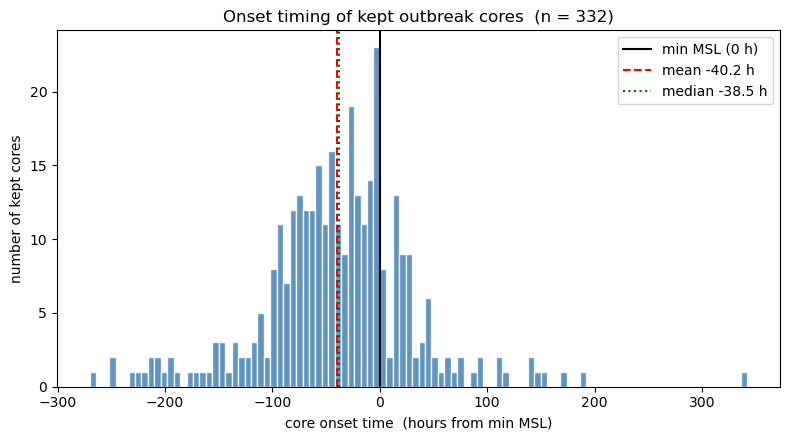

In [51]:
vals = kept['onset_h_from_min_msl'].dropna()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(vals, bins=range(int(vals.min()) - 3, int(vals.max()) + 6, 6),
        color='steelblue', edgecolor='white', alpha=0.85)

ax.axvline(0, color='k', lw=1.5, ls='-',  label='min MSL (0 h)')
ax.axvline(vals.mean(),   color='red',     lw=1.5, ls='--', label=f'mean {vals.mean():+.1f} h')
ax.axvline(vals.median(), color='darkgreen', lw=1.5, ls=':', label=f'median {vals.median():+.1f} h')

ax.set_xlabel('core onset time  (hours from min MSL)')
ax.set_ylabel('number of kept cores')
ax.set_title(f'Onset timing of kept outbreak cores  (n = {len(vals)})')
ax.legend()
plt.tight_layout()
plt.show()